Confusion Matrix
[[50  0  0]
 [ 0 47  3]
 [ 0  3 47]]
Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        50
           1       0.94      0.94      0.94        50
           2       0.94      0.94      0.94        50

    accuracy                           0.96       150
   macro avg       0.96      0.96      0.96       150
weighted avg       0.96      0.96      0.96       150



C:\Users\Artem\PycharmProjects\MLProject\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


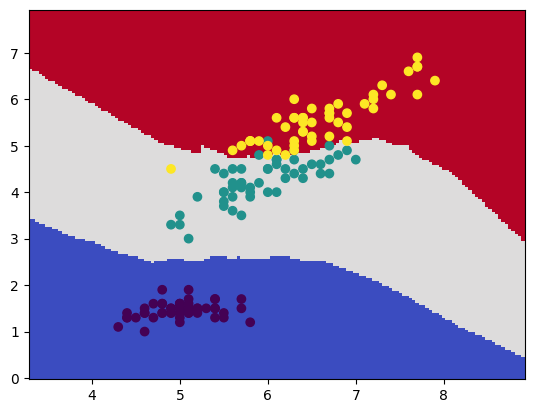

In [8]:
import pandas as pd
import numpy as np
from sklearn import metrics
from sklearn.metrics import confusion_matrix
from matplotlib import pyplot as plt
from sklearn.datasets import load_iris
from sklearn.preprocessing import MinMaxScaler
from sklearn.neighbors import KNeighborsClassifier

iris = load_iris()
data = pd.DataFrame(iris.data, columns=iris.feature_names)

X = data.iloc[:, [0, 2]]
y = iris.target

scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

def model(X_scaled, y, n):

    clf_kneighbors = KNeighborsClassifier(n_neighbors=n)
    clf_kneighbors.fit(X_scaled, y)
    y_predict1 = clf_kneighbors.predict(X_scaled)

    print('Confusion Matrix')
    print(confusion_matrix(y, y_predict1))
    print('Classification Report')
    print(metrics.classification_report(y, y_predict1))

    X0 = np.linspace(X.iloc[:, 0].min()-1,X.iloc[:, 0].max()+1, X.shape[0])
    X1 = np.linspace(X.iloc[:, 1].min()-1,X.iloc[:, 1].max()+1, X.shape[0])
    X0_grid, X1_grid = np.meshgrid(X0, X1)

    plt.figure()
    y_predict = clf_kneighbors.predict(scaler.transform(np.c_[X0_grid.ravel(),X1_grid.ravel()])).reshape(X0_grid.shape)
    plt.pcolormesh(X0_grid, X1_grid, y_predict, cmap='coolwarm')

    plt.scatter(X.iloc[:, 0], X.iloc[:, 1], c=y)
    return clf_kneighbors, y_predict1
clf_kneighbors, y_predict = model(X_scaled, y, 3)


Prediction: 2
Neighbor classes: [2 2 2]
Distances: [0.03254042 0.05555556 0.08503951]


C:\Users\Artem\PycharmProjects\MLProject\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


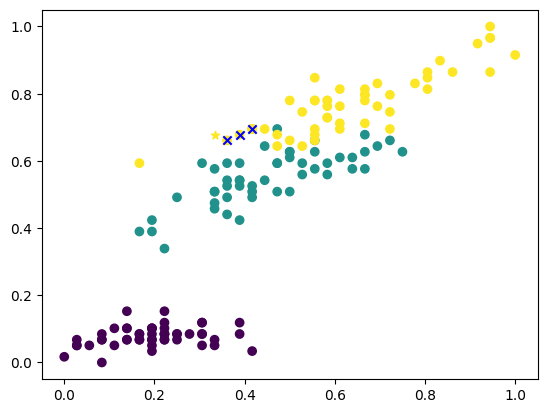

In [9]:
from matplotlib.colors import Normalize

clf_kneighbors.fit(X_scaled, y)
observation_new = [[5.5, 5]]
observation_new_scaled = scaler.transform(observation_new)
clf_kneighbors.predict(observation_new_scaled)
distances, indices = clf_kneighbors.kneighbors(observation_new_scaled)

print("Prediction:", clf_kneighbors.predict(observation_new_scaled)[0])
print("Neighbor classes:", y[indices[0]])
print("Distances:", distances[0])
classes = np.unique(y)
norm = Normalize(vmin=classes.min(), vmax=classes.max())
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=y, norm=norm)

plt.scatter(observation_new_scaled[0][0], observation_new_scaled[0][1], marker='*', c=[clf_kneighbors.predict(observation_new_scaled)], norm=norm)

plt.scatter(X_scaled[indices[0]][0][0], X_scaled[indices[0]][0][1], marker='x',c='blue')
plt.scatter(X_scaled[indices[0]][1][0], X_scaled[indices[0]][1][1], marker='x',c='blue')
plt.scatter(X_scaled[indices[0]][2][0], X_scaled[indices[0]][2][1], marker='x',c='blue')
plt.show()

Confusion Matrix
[[50  0  0]
 [ 0 50  0]
 [ 0  1 49]]
Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        50
           1       0.98      1.00      0.99        50
           2       1.00      0.98      0.99        50

    accuracy                           0.99       150
   macro avg       0.99      0.99      0.99       150
weighted avg       0.99      0.99      0.99       150

Confusion Matrix
[[50  0  0]
 [ 0 47  3]
 [ 0  4 46]]
Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        50
           1       0.92      0.94      0.93        50
           2       0.94      0.92      0.93        50

    accuracy                           0.95       150
   macro avg       0.95      0.95      0.95       150
weighted avg       0.95      0.95      0.95       150

Confusion Matrix
[[50  0  0]
 [ 0 47  3]
 [ 0  6 44]]
Classification Report
          

C:\Users\Artem\PycharmProjects\MLProject\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
C:\Users\Artem\PycharmProjects\MLProject\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
C:\Users\Artem\PycharmProjects\MLProject\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


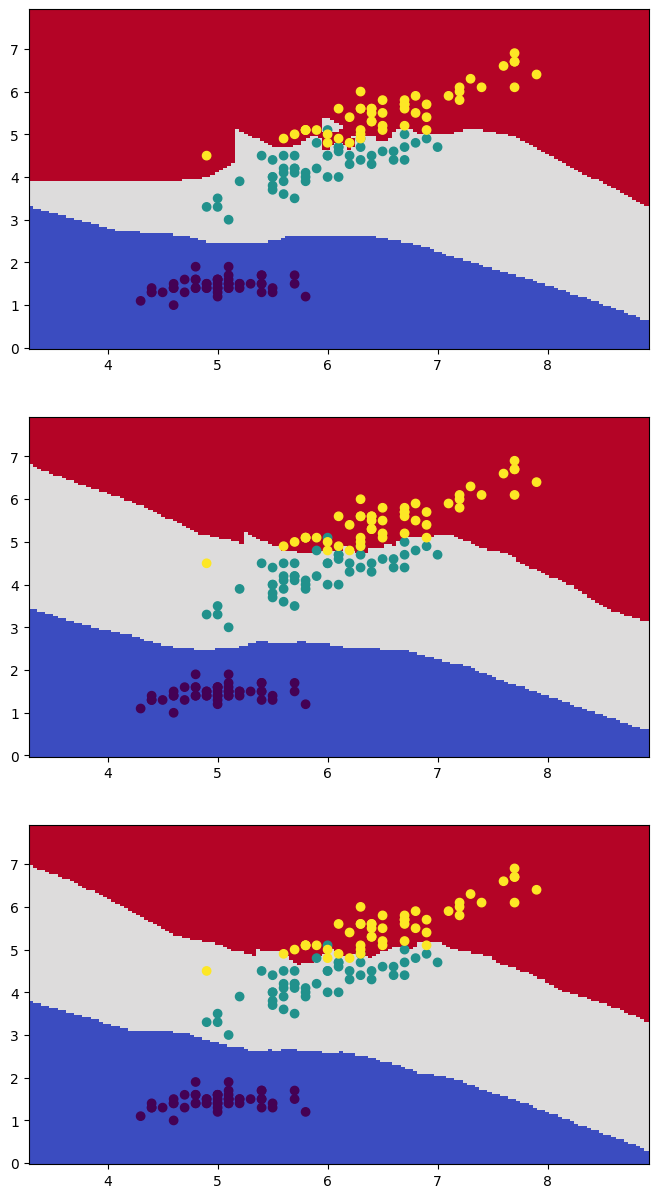

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

In [15]:
fig, ax = plt.subplots(3, 1, figsize=(8, 15))
ax = ax.ravel()
d = 0

for n in [1, 5, 10]:
    clf_kneighbors = KNeighborsClassifier(n_neighbors=n)
    clf_kneighbors.fit(X_scaled, y)
    y_predict1 = clf_kneighbors.predict(X_scaled)

    print('Confusion Matrix')
    print(confusion_matrix(y, y_predict1))
    print('Classification Report')
    print(metrics.classification_report(y, y_predict1))

    X0 = np.linspace(X.iloc[:, 0].min()-1,X.iloc[:, 0].max()+1, X.shape[0])
    X1 = np.linspace(X.iloc[:, 1].min()-1,X.iloc[:, 1].max()+1, X.shape[0])
    X0_grid, X1_grid = np.meshgrid(X0, X1)

    plt.figure()
    y_predict = clf_kneighbors.predict(scaler.transform(np.c_[X0_grid.ravel(),X1_grid.ravel()])).reshape(X0_grid.shape)
    ax[d].pcolormesh(X0_grid, X1_grid, y_predict, cmap='coolwarm')

    ax[d].scatter(X.iloc[:, 0], X.iloc[:, 1], c=y)
    d += 1

C:\Users\Artem\PycharmProjects\MLProject\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


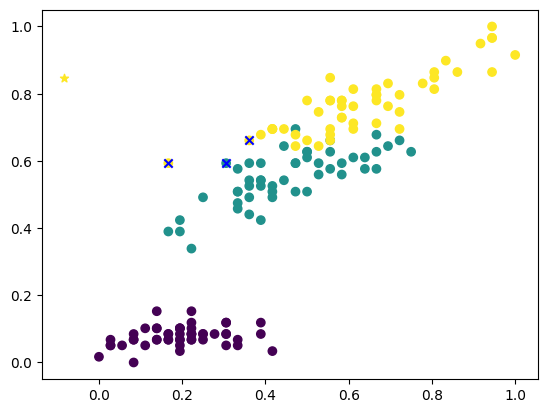

In [5]:
observation_new = [[4, 6]]
observation_new_scaled = scaler.transform(observation_new)
clf_kneighbors.predict(observation_new_scaled)
distances, indices = clf_kneighbors.kneighbors(observation_new_scaled)
classes = np.unique(y)
norm = Normalize(vmin=classes.min(), vmax=classes.max())
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=y, norm=norm)

plt.scatter(observation_new_scaled[0][0], observation_new_scaled[0][1], marker='*', c=clf_kneighbors.predict(observation_new_scaled)[0], norm=norm)

plt.scatter(X_scaled[indices[0]][0][0], X_scaled[indices[0]][0][1], marker='x',c='blue')
plt.scatter(X_scaled[indices[0]][1][0], X_scaled[indices[0]][1][1], marker='x',c='blue')
plt.scatter(X_scaled[indices[0]][2][0], X_scaled[indices[0]][2][1], marker='x',c='blue')
plt.show()


Euclidean
Confusion Matrix
[[50  0  0]
 [ 0 47  3]
 [ 0  6 44]]

Manhattan
Confusion Matrix
[[50  0  0]
 [ 0 47  3]
 [ 0  6 44]]

Cosine
Confusion Matrix
[[50  0  0]
 [ 0 47  3]
 [ 0  6 44]]

Chebyshev
Confusion Matrix
[[50  0  0]
 [ 0 47  3]
 [ 0  6 44]]


C:\Users\Artem\PycharmProjects\MLProject\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
C:\Users\Artem\PycharmProjects\MLProject\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
C:\Users\Artem\PycharmProjects\MLProject\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
C:\Users\Artem\PycharmProjects\MLProject\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
C:\Users\Artem\PycharmProjects\MLProject\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names,

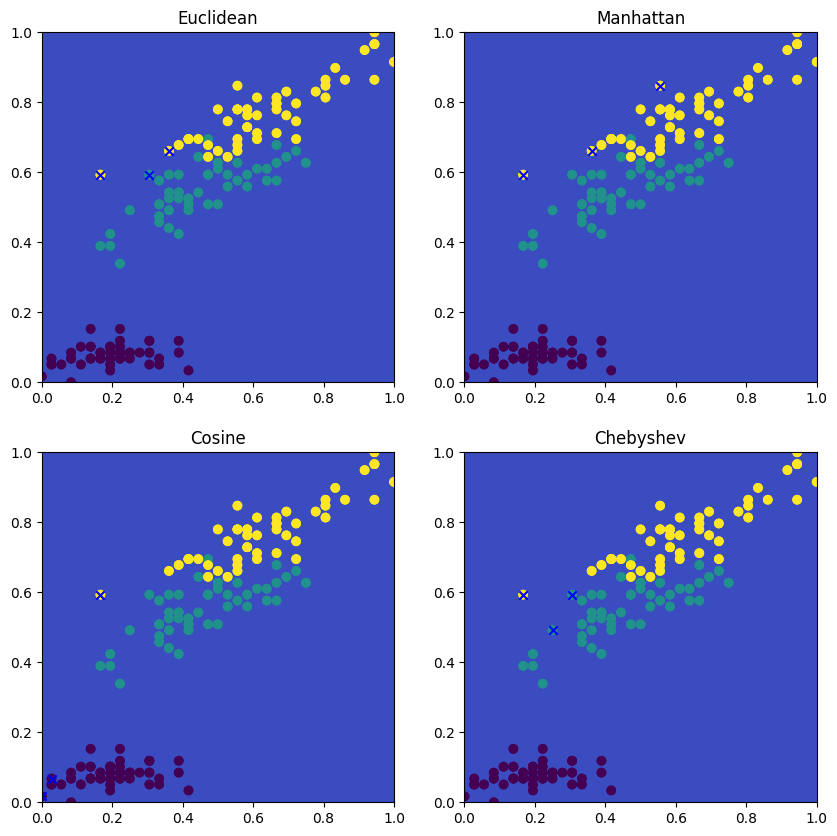

In [30]:
metrics_ = {
    'Euclidean': 'euclidean',
    'Manhattan': 'manhattan',
    'Cosine': 'cosine',
    'Chebyshev': 'chebyshev'
}

fig, ax = plt.subplots(2, 2, figsize=(10, 10))
ax = ax.ravel()

d = 0

for name, metric in metrics_.items():
    knn = KNeighborsClassifier(n_neighbors=3, metric=metric)
    knn.fit(X_scaled, y)
    y_predict1 = clf_kneighbors.predict(X_scaled)

    print()
    print(name)
    print('Confusion Matrix')
    print(confusion_matrix(y, y_predict1))
    # print('Classification Report')
    # print(metrics.classification_report(y, y_predict1))

    X0 = np.linspace(X_scaled[:, 0].min()-1,X_scaled[:, 0].max()+1, X.shape[0])
    X1 = np.linspace(X_scaled[:, 1].min()-1,X_scaled[:, 1].max()+1, X.shape[0])
    X0_grid, X1_grid = np.meshgrid(X0, X1)

    y_predict = clf_kneighbors.predict(scaler.transform(np.c_[X0_grid.ravel(),X1_grid.ravel()])).reshape(X0_grid.shape)
    ax[d].pcolormesh(X0_grid, X1_grid, y_predict, cmap='coolwarm')

    ax[d].scatter(X_scaled[:, 0], X_scaled[:, 1], c=y)


    observation_new = [[4, 6]]
    observation_new_scaled = scaler.transform(observation_new)
    knn.predict(observation_new_scaled)
    distances, indices = knn.kneighbors(observation_new_scaled)
    classes = np.unique(y)
    norm = Normalize(vmin=classes.min(), vmax=classes.max())
    ax[d].scatter(X_scaled[:, 0], X_scaled[:, 1], c=y, norm=norm)

    ax[d].scatter(observation_new_scaled[0][0], observation_new_scaled[0][1], marker='*', c=knn.predict(observation_new_scaled)[0], norm=norm)

    ax[d].scatter(X_scaled[indices[0]][0][0], X_scaled[indices[0]][0][1], marker='x',c='blue')
    ax[d].scatter(X_scaled[indices[0]][1][0], X_scaled[indices[0]][1][1], marker='x',c='blue')
    ax[d].scatter(X_scaled[indices[0]][2][0], X_scaled[indices[0]][2][1], marker='x',c='blue')
    ax[d].set_title(name)
    ax[d].set_xlim(0, 1)
    ax[d].set_ylim(0, 1)
    d += 1
plt.show()


3
Confusion Matrix
[[50  0  0]
 [ 0 48  2]
 [ 0  3 47]]
Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        50
           1       0.94      0.96      0.95        50
           2       0.96      0.94      0.95        50

    accuracy                           0.97       150
   macro avg       0.97      0.97      0.97       150
weighted avg       0.97      0.97      0.97       150


5
Confusion Matrix
[[50  0  0]
 [ 0 48  2]
 [ 0  4 46]]
Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        50
           1       0.92      0.96      0.94        50
           2       0.96      0.92      0.94        50

    accuracy                           0.96       150
   macro avg       0.96      0.96      0.96       150
weighted avg       0.96      0.96      0.96       150


10
Confusion Matrix
[[50  0  0]
 [ 0 49  1]
 [ 0  4 46]]
Classification Report


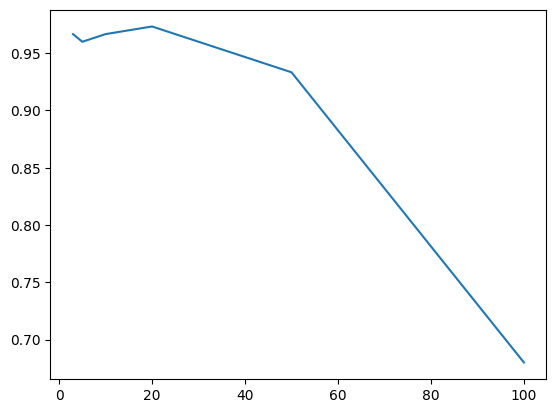

In [36]:
iris = load_iris()
data = pd.DataFrame(iris.data, columns=iris.feature_names)

X = data
y = iris.target

scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

acc = []

k_s = [3, 5, 10, 20, 50, 100]

for n in k_s:
    clf_kneighbors = KNeighborsClassifier(n_neighbors=n)
    clf_kneighbors.fit(X_scaled, y)
    y_predict1 = clf_kneighbors.predict(X_scaled)
    print()
    print(n)
    print('Confusion Matrix')
    print(confusion_matrix(y, y_predict1))
    print('Classification Report')
    print(metrics.classification_report(y, y_predict1))

    acc.append(metrics.accuracy_score(y, y_predict1))

plt.plot(k_s, acc)
plt.show()


In [43]:
from sklearn.datasets import fetch_california_housing
from sklearn.neighbors import KNeighborsRegressor

data = fetch_california_housing()
df = pd.DataFrame(data.data, columns=data.feature_names)

X = df
y = data.target

scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

clf_kneighbors = KNeighborsRegressor(n_neighbors=5)
clf_kneighbors.fit(X_scaled, y)
y_predict1 = clf_kneighbors.predict(X_scaled)

print('R2 Score')
print(metrics.r2_score(y, y_predict1))
print('MAE')
print(metrics.mean_absolute_error(y, y_predict1))

R2 Score
0.8082638858161266
MAE
0.33746726269379845
